# Pre-1870 Old Stock Ancestry: National Estimates, 1870-2020

This notebook runs the agent-based national ancestry model and visualizes:

1. **Percentage** of the U.S. population that is majority old-stock (non-Black pre-1870 resident ancestry) vs. not, decade by decade.
2. **Raw headcount** of those groups anchored to actual Census population totals.
3. **State-level map** of estimated old-stock ancestry share.
4. **Hypothetical 2024 Electoral College map** if only old-stock Americans were counted in the census.

See `ASSUMPTIONS.md` for full model documentation.

In [1]:
import sys, os, pathlib
sys.path.insert(0, str(pathlib.Path(os.getcwd()).parent / "scripts"))

from dataclasses import asdict
from pre1870_ancestry_model import ModelParams, DECADE_DATA, simulate
from state_pre1870_ancestry_model import (
    FALLBACK_STATES, ModelParams as StateModelParams, estimate_states, weighted_mean,
)
from hypothetical_ec_reapportionment import (
    apportion_house_huntington_hill, EV_2024,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# ---------------------------------------------------------------------------
# Substack-style theme
# ---------------------------------------------------------------------------
SUBSTACK_BG      = "#F7F5F0"
SUBSTACK_CARD    = "#EFEDE8"
SUBSTACK_TEXT    = "#1A1A1A"
SUBSTACK_MUTED   = "#6B6B6B"
SUBSTACK_ACCENT  = "#C85A3D"
SUBSTACK_BLUE    = "#3D6F8C"
SUBSTACK_GOLD    = "#C2993E"
SUBSTACK_GREEN   = "#4A7C59"
SUBSTACK_GRID    = "#D6D3CC"

plt.rcParams.update({
    "figure.facecolor":   SUBSTACK_BG,
    "axes.facecolor":     SUBSTACK_BG,
    "savefig.facecolor":  SUBSTACK_BG,
    "text.color":         SUBSTACK_TEXT,
    "axes.labelcolor":    SUBSTACK_TEXT,
    "xtick.color":        SUBSTACK_MUTED,
    "ytick.color":        SUBSTACK_MUTED,
    "axes.edgecolor":     SUBSTACK_GRID,
    "grid.color":         SUBSTACK_GRID,
    "grid.alpha":         0.6,
    "grid.linewidth":     0.5,
    "font.family":        "serif",
    "font.size":          12,
    "axes.titlesize":     16,
    "axes.labelsize":     13,
    "figure.titlesize":   18,
    "legend.framealpha":  0.0,
    "legend.fontsize":    11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

print("Setup complete.")

Setup complete.


## 1. Run the national agent-based model

In [2]:
params = ModelParams(n_agents=300_000, seed=1870)
results = simulate(params)

years       = [r.year for r in results]
populations = [d.total_population for d in DECADE_DATA]

pct_majority_old_stock = [r.primary_qualifying_ancestry_share for r in results]
pct_any_old_stock      = [r.any_qualifying_ancestor_share for r in results]
pct_avg_ancestry       = [r.average_qualifying_ancestry for r in results]

pct_not_majority = [1.0 - p for p in pct_majority_old_stock]

raw_majority   = [pop * pct for pop, pct in zip(populations, pct_majority_old_stock)]
raw_not        = [pop * pct for pop, pct in zip(populations, pct_not_majority)]

df_national = pd.DataFrame({
    "year":               years,
    "population":         populations,
    "pct_majority_old":   pct_majority_old_stock,
    "pct_any_old":        pct_any_old_stock,
    "pct_avg_ancestry":   pct_avg_ancestry,
    "pct_not_majority":   pct_not_majority,
    "count_majority_old": raw_majority,
    "count_not_majority": raw_not,
})

df_national.style.format({
    "population":         "{:,.0f}",
    "pct_majority_old":   "{:.1%}",
    "pct_any_old":        "{:.1%}",
    "pct_avg_ancestry":   "{:.1%}",
    "pct_not_majority":   "{:.1%}",
    "count_majority_old": "{:,.0f}",
    "count_not_majority": "{:,.0f}",
})

,year,population,pct_majority_old,pct_any_old,pct_avg_ancestry,pct_not_majority,count_majority_old,count_not_majority
0,1870,"38,558,371",87.4%,87.4%,87.4%,12.6%,"33,680,866","4,877,505"
1,1880,"50,189,209",80.3%,82.9%,81.0%,19.7%,"40,277,844","9,911,365"
2,1890,"62,979,766",71.1%,76.4%,72.6%,28.9%,"44,779,243","18,200,523"
3,1900,"76,212,168",65.6%,73.9%,67.9%,34.4%,"49,964,697","26,247,471"
4,1910,"92,228,496",57.0%,67.4%,59.7%,43.0%,"52,614,512","39,613,984"
5,1920,"106,021,537",52.1%,65.1%,55.3%,47.9%,"55,259,485","50,762,052"
6,1930,"123,202,624",49.3%,64.7%,52.7%,50.7%,"60,678,935","62,523,689"
7,1940,"132,164,569",48.2%,66.4%,51.9%,51.8%,"63,764,999","68,399,570"
8,1950,"151,325,798",47.2%,67.9%,50.8%,52.8%,"71,403,078","79,922,720"
9,1960,"179,323,175",46.0%,69.1%,49.4%,54.0%,"82,419,322","96,903,853"


## 2. Share of America that is majority old-stock over time

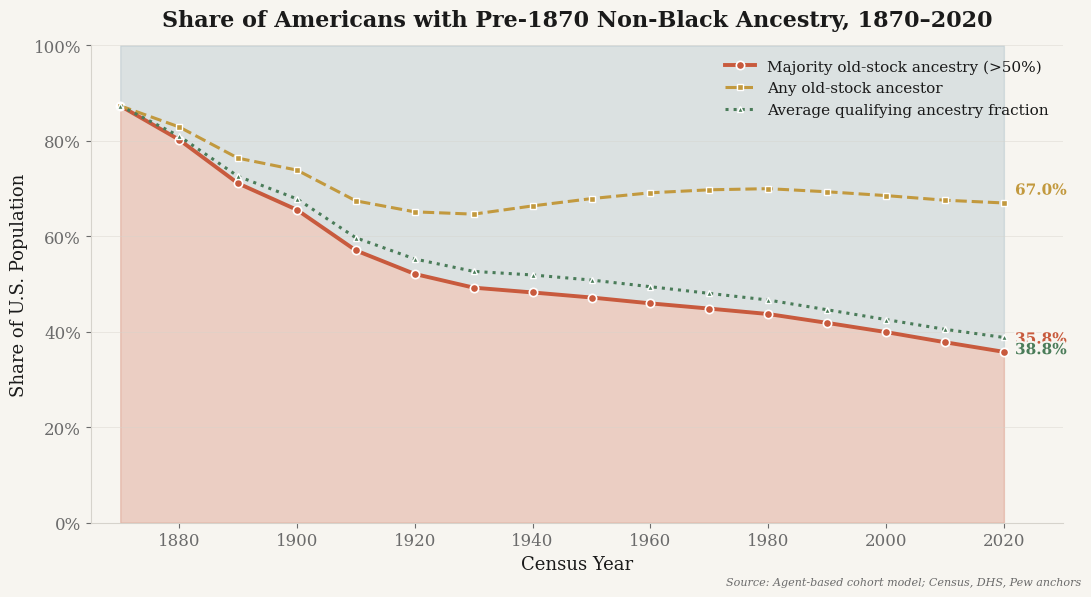

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(years, [p * 100 for p in pct_majority_old_stock], 0,
                color=SUBSTACK_ACCENT, alpha=0.25, label="_nolegend_")
ax.fill_between(years, 100, [p * 100 for p in pct_majority_old_stock],
                color=SUBSTACK_BLUE, alpha=0.15, label="_nolegend_")

ax.plot(years, [p * 100 for p in pct_majority_old_stock],
        color=SUBSTACK_ACCENT, linewidth=2.8, marker="o", markersize=6,
        markeredgecolor="white", markeredgewidth=1.2,
        label="Majority old-stock ancestry (>50%)")
ax.plot(years, [p * 100 for p in pct_any_old_stock],
        color=SUBSTACK_GOLD, linewidth=2.2, marker="s", markersize=5,
        markeredgecolor="white", markeredgewidth=1.0,
        label="Any old-stock ancestor", linestyle="--")
ax.plot(years, [p * 100 for p in pct_avg_ancestry],
        color=SUBSTACK_GREEN, linewidth=2.2, marker="^", markersize=5,
        markeredgecolor="white", markeredgewidth=1.0,
        label="Average qualifying ancestry fraction", linestyle=":")

# Annotations at 2020
for val, label, color, va in [
    (pct_majority_old_stock[-1], f"{pct_majority_old_stock[-1]:.1%}", SUBSTACK_ACCENT, "bottom"),
    (pct_any_old_stock[-1],     f"{pct_any_old_stock[-1]:.1%}",      SUBSTACK_GOLD,   "bottom"),
    (pct_avg_ancestry[-1],      f"{pct_avg_ancestry[-1]:.1%}",       SUBSTACK_GREEN,  "top"),
]:
    ax.annotate(label, xy=(2020, val * 100), xytext=(8, 6 if va == "bottom" else -12),
                textcoords="offset points", fontsize=11, fontweight="bold", color=color,
                path_effects=[pe.withStroke(linewidth=3, foreground=SUBSTACK_BG)])

ax.set_xlim(1865, 2030)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Census Year")
ax.set_ylabel("Share of U.S. Population")
ax.set_title("Share of Americans with Pre-1870 Non-Black Ancestry, 1870–2020",
             fontweight="bold", pad=14)
ax.legend(loc="upper right", frameon=False)
ax.grid(axis="y", linestyle="-", linewidth=0.5)

fig.text(0.99, 0.01, "Source: Agent-based cohort model; Census, DHS, Pew anchors",
         ha="right", fontsize=8, color=SUBSTACK_MUTED, style="italic")
plt.tight_layout()
plt.savefig("../outputs/pct_old_stock_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Raw headcount: majority old-stock vs. not

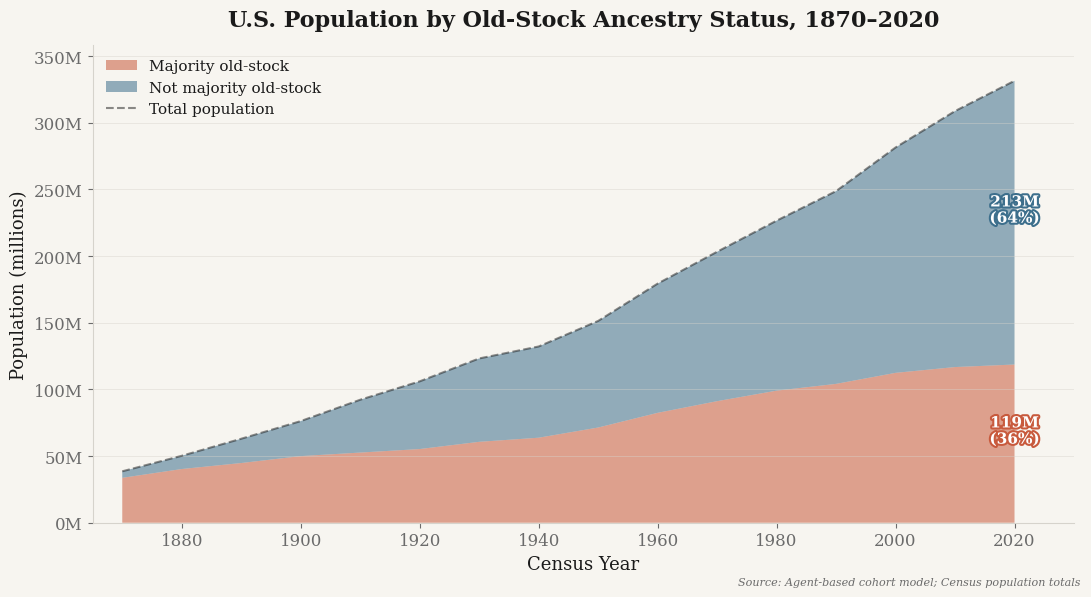

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

raw_maj_m = [x / 1e6 for x in raw_majority]
raw_not_m = [x / 1e6 for x in raw_not]
pop_m     = [x / 1e6 for x in populations]

ax.stackplot(years, raw_maj_m, raw_not_m,
             colors=[SUBSTACK_ACCENT, SUBSTACK_BLUE],
             alpha=0.55,
             labels=["Majority old-stock", "Not majority old-stock"])

ax.plot(years, pop_m, color=SUBSTACK_TEXT, linewidth=1.5, linestyle="--",
        alpha=0.5, label="Total population")

# Annotate 2020 values
y_maj = raw_maj_m[-1]
y_not = raw_not_m[-1]
y_tot = pop_m[-1]
ax.annotate(f"{y_maj:.0f}M\n({pct_majority_old_stock[-1]:.0%})",
            xy=(2020, y_maj / 2), fontsize=11, fontweight="bold",
            color="white", ha="center",
            path_effects=[pe.withStroke(linewidth=3, foreground=SUBSTACK_ACCENT)])
ax.annotate(f"{y_not:.0f}M\n({pct_not_majority[-1]:.0%})",
            xy=(2020, y_maj + y_not / 2), fontsize=11, fontweight="bold",
            color="white", ha="center",
            path_effects=[pe.withStroke(linewidth=3, foreground=SUBSTACK_BLUE)])

ax.set_xlim(1865, 2030)
ax.set_ylim(0, max(pop_m) * 1.08)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.set_xlabel("Census Year")
ax.set_ylabel("Population (millions)")
ax.set_title("U.S. Population by Old-Stock Ancestry Status, 1870–2020",
             fontweight="bold", pad=14)
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", linestyle="-", linewidth=0.5)

fig.text(0.99, 0.01, "Source: Agent-based cohort model; Census population totals",
         ha="right", fontsize=8, color=SUBSTACK_MUTED, style="italic")
plt.tight_layout()
plt.savefig("../outputs/raw_headcount_old_stock.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. State-level old-stock ancestry map

Uses the state-level reduced-form model with built-in fallback priors (50 states + DC).

In [5]:
state_params = StateModelParams()
inputs = sorted(FALLBACK_STATES, key=lambda x: x.state)
estimates = estimate_states(inputs, state_params)

df_state = pd.DataFrame([asdict(e) for e in estimates])
df_state["qualifying_pct"] = df_state["primary_qualifying_ancestry_share"] * 100

# Build the counted population and reapportion
df_state["counted_population"] = df_state["population"] * df_state["primary_qualifying_ancestry_share"]

state_pops = dict(zip(
    df_state[df_state["abbr"] != "DC"]["abbr"],
    df_state[df_state["abbr"] != "DC"]["counted_population"],
))
hyp_house = apportion_house_huntington_hill(state_pops)

df_state["actual_ev_2024"]    = df_state["abbr"].map(EV_2024)
df_state["hypothetical_house"] = df_state["abbr"].map(hyp_house).fillna(0).astype(int)
df_state["hypothetical_ev"]   = df_state.apply(
    lambda r: 3 if r["abbr"] == "DC" else r["hypothetical_house"] + 2, axis=1
)
df_state["ev_change"] = df_state["hypothetical_ev"] - df_state["actual_ev_2024"]

print(f"States modeled: {len(df_state)}")
print(f"National weighted primary share: {weighted_mean(estimates, 'primary_qualifying_ancestry_share'):.1%}")
print(f"Total actual 2024 EV: {df_state['actual_ev_2024'].sum()}")
print(f"Total hypothetical EV: {df_state['hypothetical_ev'].sum()}")

States modeled: 51
National weighted primary share: 37.2%
Total actual 2024 EV: 538
Total hypothetical EV: 538


In [6]:
import geopandas as gpd

SHAPEFILE = pathlib.Path(os.getcwd()).parent / "data" / "geo" / "cb_2020_us_state_20m.zip"
us = gpd.read_file(SHAPEFILE)

# Filter to 50 states + DC, exclude territories
TERRITORIES = {"AS", "GU", "MP", "PR", "VI"}
us = us[~us["STUSPS"].isin(TERRITORIES)].copy()

# Shift Alaska and Hawaii for CONUS-style layout
def shift_ak_hi(gdf):
    from shapely.affinity import translate, scale
    gdf = gdf.copy()
    ak = gdf["STUSPS"] == "AK"
    hi = gdf["STUSPS"] == "HI"
    gdf.loc[ak, "geometry"] = gdf.loc[ak, "geometry"].apply(
        lambda g: translate(scale(g, xfact=0.35, yfact=0.35, origin=(0, 0)), xoff=1200000, yoff=-4900000)
    )
    gdf.loc[hi, "geometry"] = gdf.loc[hi, "geometry"].apply(
        lambda g: translate(g, xoff=5250000, yoff=-1400000)
    )
    return gdf

us = us.to_crs("ESRI:102003")  # USA Contiguous Albers Equal Area
us = shift_ak_hi(us)

# Merge with state estimates
us = us.merge(df_state, left_on="STUSPS", right_on="abbr", how="left")

print(f"Merged: {len(us)} states with geometry")

Merged: 51 states with geometry


### Map A: Primary old-stock ancestry share by state

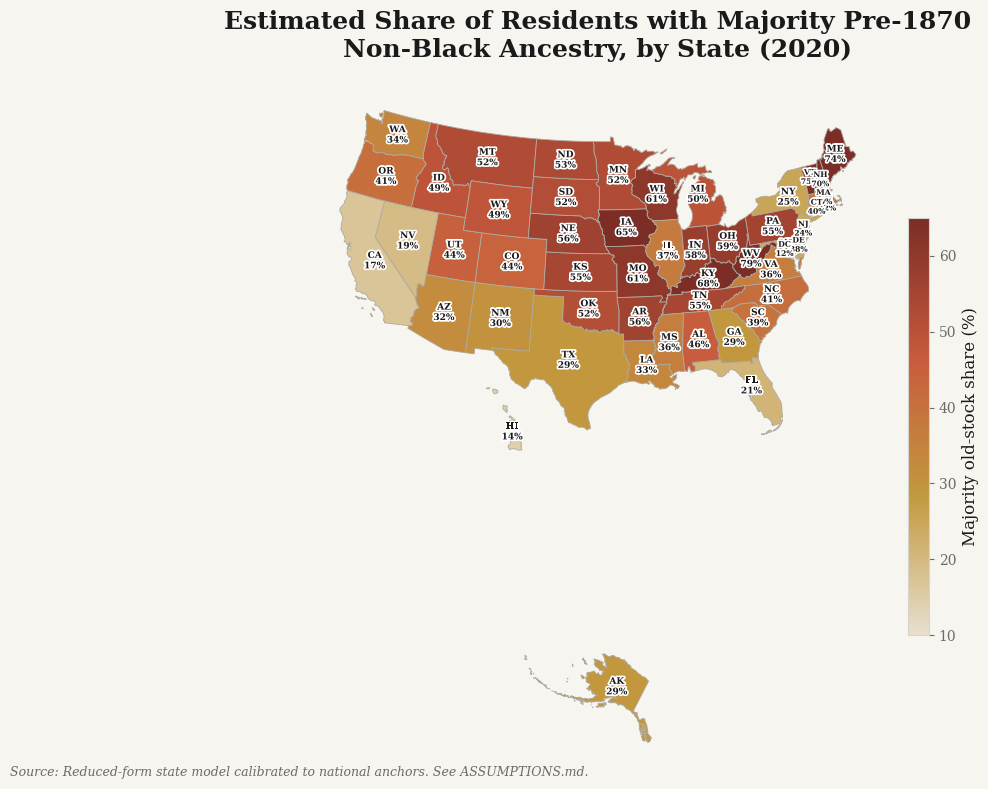

In [7]:
old_stock_cmap = LinearSegmentedColormap.from_list(
    "old_stock", ["#E8DFCE", SUBSTACK_GOLD, SUBSTACK_ACCENT, "#7B2D26"], N=256
)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_axis_off()

us.plot(
    column="qualifying_pct",
    cmap=old_stock_cmap,
    linewidth=0.6,
    edgecolor="#AEAAA0",
    legend=False,
    ax=ax,
    vmin=10,
    vmax=65,
)

sm = plt.cm.ScalarMappable(cmap=old_stock_cmap, norm=plt.Normalize(vmin=10, vmax=65))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label("Majority old-stock share (%)", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_edgecolor(SUBSTACK_GRID)

# State labels
for _, row in us.iterrows():
    centroid = row.geometry.centroid
    label = f"{row['STUSPS']}\n{row['qualifying_pct']:.0f}%"
    fontsize = 6.5 if row["STUSPS"] not in ("DC", "RI", "DE", "CT", "NJ", "NH", "VT", "MA", "MD") else 5.5
    ax.annotate(label, xy=(centroid.x, centroid.y), ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color=SUBSTACK_TEXT,
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

ax.set_title("Estimated Share of Residents with Majority Pre-1870\nNon-Black Ancestry, by State (2020)",
             fontsize=18, fontweight="bold", pad=16)
fig.text(0.5, 0.02,
         "Source: Reduced-form state model calibrated to national anchors. See ASSUMPTIONS.md.",
         ha="center", fontsize=9, color=SUBSTACK_MUTED, style="italic")

plt.tight_layout()
plt.savefig("../outputs/map_old_stock_pct_by_state.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Hypothetical 2024 Electoral College map

If the census only counted residents with majority pre-1870 non-Black ancestry, how would the 435 House seats (and therefore electoral votes) be redistributed?

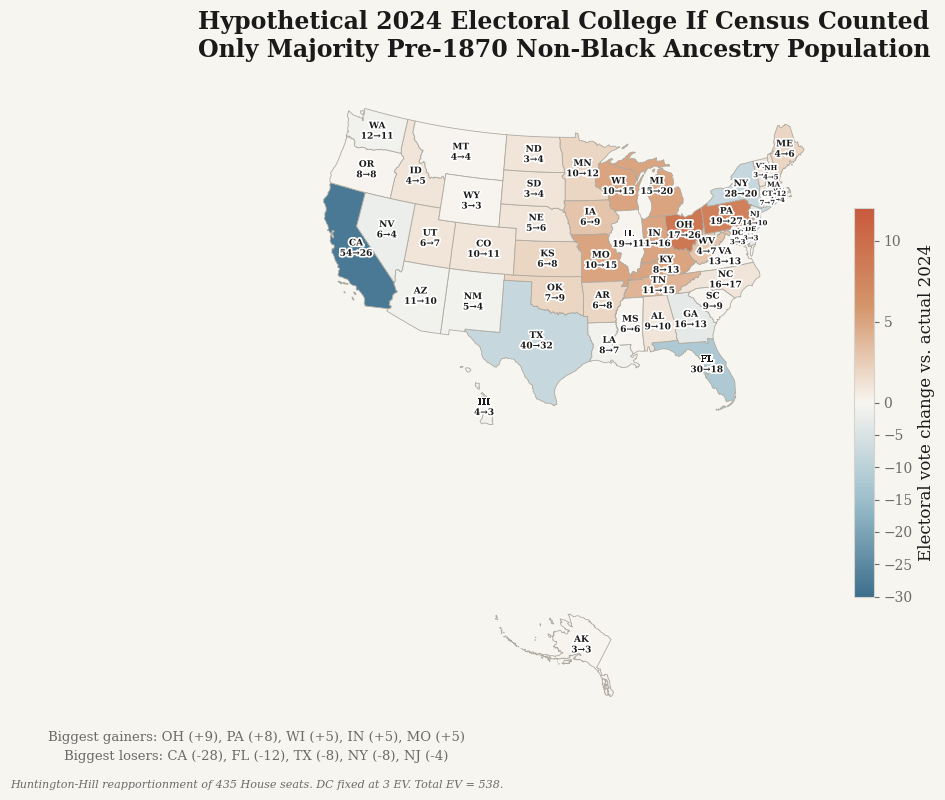

In [8]:
ev_cmap = LinearSegmentedColormap.from_list(
    "ev_change", [SUBSTACK_BLUE, "#9DBFCC", SUBSTACK_BG, "#D4956A", SUBSTACK_ACCENT], N=256
)
ev_norm = TwoSlopeNorm(vmin=-30, vcenter=0, vmax=12)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_axis_off()

us.plot(
    column="ev_change",
    cmap=ev_cmap,
    norm=ev_norm,
    linewidth=0.6,
    edgecolor="#AEAAA0",
    legend=False,
    ax=ax,
)

sm = plt.cm.ScalarMappable(cmap=ev_cmap, norm=ev_norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label("Electoral vote change vs. actual 2024", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_edgecolor(SUBSTACK_GRID)

# State labels showing actual -> hypothetical
for _, row in us.iterrows():
    centroid = row.geometry.centroid
    change = int(row["ev_change"])
    sign = "+" if change > 0 else ""
    label = f"{row['STUSPS']}\n{int(row['actual_ev_2024'])}→{int(row['hypothetical_ev'])}"
    fontsize = 6.5 if row["STUSPS"] not in ("DC", "RI", "DE", "CT", "NJ", "NH", "VT", "MA", "MD") else 5
    color = SUBSTACK_TEXT
    ax.annotate(label, xy=(centroid.x, centroid.y), ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color=color,
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

ax.set_title("Hypothetical 2024 Electoral College If Census Counted\nOnly Majority Pre-1870 Non-Black Ancestry Population",
             fontsize=17, fontweight="bold", pad=16)

# Summary stats
gainers = us[us["ev_change"] > 0].sort_values("ev_change", ascending=False)
losers  = us[us["ev_change"] < 0].sort_values("ev_change")
top_gain = ", ".join(f"{r['STUSPS']} ({int(r['ev_change']):+d})" for _, r in gainers.head(5).iterrows())
top_lose = ", ".join(f"{r['STUSPS']} ({int(r['ev_change']):+d})" for _, r in losers.head(5).iterrows())

fig.text(0.5, 0.04,
         f"Biggest gainers: {top_gain}\nBiggest losers: {top_lose}",
         ha="center", fontsize=9.5, color=SUBSTACK_MUTED, linespacing=1.6)
fig.text(0.5, 0.005,
         "Huntington-Hill reapportionment of 435 House seats. DC fixed at 3 EV. Total EV = 538.",
         ha="center", fontsize=8, color=SUBSTACK_MUTED, style="italic")

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("../outputs/map_hypothetical_ec_2024.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Summary table: top gainers and losers

In [9]:
display_cols = ["state", "abbr", "qualifying_pct", "actual_ev_2024", "hypothetical_ev", "ev_change"]
rename = {"state": "State", "abbr": "Abbr", "qualifying_pct": "Old-Stock %",
          "actual_ev_2024": "Actual EV", "hypothetical_ev": "Hyp. EV", "ev_change": "Change"}

combined = pd.concat([
    pd.DataFrame(us.nlargest(10, "ev_change")[display_cols]),
    pd.DataFrame(us.nsmallest(10, "ev_change")[display_cols]),
]).rename(columns=rename)

combined.style.format({"Old-Stock %": "{:.1f}%"}).bar(
    subset=["Change"], color=[SUBSTACK_BLUE, SUBSTACK_ACCENT], align="zero"
)

,State,Abbr,Old-Stock %,Actual EV,Hyp. EV,Change
41,Ohio,OH,58.6%,17,26,9
26,Pennsylvania,PA,55.5%,19,27,8
1,Wisconsin,WI,60.5%,10,15,5
5,Missouri,MO,60.5%,10,15,5
8,Michigan,MI,49.6%,15,20,5
16,Kentucky,KY,67.7%,8,13,5
29,Indiana,IN,57.9%,11,16,5
17,Tennessee,TN,54.9%,11,15,4
4,Iowa,IA,65.1%,6,9,3
24,West Virginia,WV,79.4%,4,7,3
